# Taller B3-T1 - Preprocesado de datos financieros para ML

Aplicación de bars, diferenciación fraccional, limpieza de covarianzas, triple barrera y validación cruzada temporal sobre datos intradía de criptomonedas.

**Integrantes:** Hugo Vinuesa y Rodolfo Villena  
**Fecha:** 15-03-2026


## Objetivo y plan

El objetivo de este notebook es aplicar cinco técnicas de preprocesado financiero orientadas a Machine Learning sobre datos intradía. El trabajo sigue un pipeline secuencial: construcción de barras por actividad, diferenciación fraccional, análisis y limpieza de covarianza, etiquetado por triple barrera y diseño de validación temporal con gap. En cada bloque se comparan parámetros alternativos y se acompañan los resultados con gráficas e interpretación. El foco no es entrenar un modelo final, sino justificar de forma visual y técnica cómo cambia la estructura del dato en cada etapa.


In [4]:
# -----------------------------------------------------------------------------
# Importación de librerías y detección opcional de statsmodels.
# -----------------------------------------------------------------------------

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

try:
    from statsmodels.graphics.tsaplots import plot_acf
    from statsmodels.tsa.stattools import adfuller
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

warnings.filterwarnings("ignore")



In [5]:
# -----------------------------------------------------------------------------
# Configuración visual global y definición de rutas/columnas.
# -----------------------------------------------------------------------------

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

BASE_PATH = Path(".")
DATA_PATH = BASE_PATH / "data"

KLINE_COLUMNS = [

    "open_time", "open", "high", "low", "close", "volume",
    "close_time", "quote_asset_volume", "n_trades",
    "taker_buy_base", "taker_buy_quote", "ignore"
]

AGG_COLUMNS = [
    "agg_trade_id", "price", "qty", "first_trade_id", "last_trade_id",
    "timestamp", "is_buyer_maker", "is_best_match"
]


## Dataset utilizado

Se trabaja con datos de criptomonedas descargados de BINANCE por su alta actividad intradía y porque permiten observar cambios de microestructura con facilidad.

Para la parte multiactivo usamos velas de 1 minuto de:

+ BNBUSDT
+ BTCUSDT
+ ETHUSDT
+ SOLUSDT 
+ XRPUSDT. 

Para construir barras por actividad usamos datos de `aggTrades` de BTCUSDT, ya que contienen cada transacción agregada con precio, cantidad y timestamp. 

BTCUSDT se usa como activo principal para los bloques que requieren una serie única.

In [6]:
# -----------------------------------------------------------------------------
# Carga de CSV intradía y trades agregados, con parseo de tipos.
# -----------------------------------------------------------------------------

symbols_1m = ["BNBUSDT", "BTCUSDT", "ETHUSDT", "SOLUSDT", "XRPUSDT"]
assets_1m = {
    symbol: sorted(DATA_PATH.glob(f"{symbol}-1m-*.csv"))
    for symbol in symbols_1m
}

# Comprobamos de forma robusta en qué unidad de tiempo están los timestamps
def infer_time_unit(values: pd.Series) -> str:
    numeric = pd.to_numeric(values, errors="coerce").dropna()
    if numeric.empty:
        raise ValueError("No hay timestamps válidos para inferir unidad")

    sample = abs(float(numeric.iloc[len(numeric) // 2]))
    if sample >= 1e17:
        return "ns"
    if sample >= 1e14:
        return "us"
    if sample >= 1e11:
        return "ms"
    return "s"


data_1m = {}
open_time_units = {}
months_loaded_1m = {}
for symbol, file_paths in assets_1m.items():
    if not file_paths:
        raise FileNotFoundError(f"No se encontraron CSV 1m para {symbol} en {DATA_PATH}")

    df = pd.concat(
        [pd.read_csv(file_path, header=None, names=KLINE_COLUMNS) for file_path in file_paths],
        ignore_index=True,
    )

    if pd.isna(pd.to_numeric(df.loc[0, "open_time"], errors="coerce")):
        df = df.iloc[1:].reset_index(drop=True)

    time_unit = infer_time_unit(df["open_time"])
    open_time_units[symbol] = time_unit

    df["open_time"] = pd.to_datetime(pd.to_numeric(df["open_time"], errors="coerce"), unit=time_unit, utc=True)
    df["close_time"] = pd.to_datetime(pd.to_numeric(df["close_time"], errors="coerce"), unit=time_unit, utc=True)

    for col in ["open", "high", "low", "close", "volume", "quote_asset_volume"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.sort_values("open_time").reset_index(drop=True)
    data_1m[symbol] = df
    months_loaded_1m[symbol] = len(file_paths)

agg_files = sorted(DATA_PATH.glob("BTCUSDT-aggTrades-*.csv"))
if not agg_files:
    raise FileNotFoundError(f"No se encontraron CSV aggTrades en {DATA_PATH}")

btc_trades = pd.concat([pd.read_csv(fp, header=None, names=AGG_COLUMNS) for fp in agg_files], ignore_index=True)

if pd.isna(pd.to_numeric(btc_trades.loc[0, "timestamp"], errors="coerce")):
    btc_trades = btc_trades.iloc[1:].reset_index(drop=True)

trade_time_unit = infer_time_unit(btc_trades["timestamp"])
btc_trades["timestamp"] = pd.to_datetime(pd.to_numeric(btc_trades["timestamp"], errors="coerce"), unit=trade_time_unit, utc=True)
btc_trades["price"] = pd.to_numeric(btc_trades["price"], errors="coerce")
btc_trades["qty"] = pd.to_numeric(btc_trades["qty"], errors="coerce")
btc_trades["dollar_value"] = btc_trades["price"] * btc_trades["qty"]
btc_trades = btc_trades.sort_values("timestamp").reset_index(drop=True)

print("Activos 1m cargados:", list(data_1m.keys()))
print("Ficheros 1m cargados por activo:", months_loaded_1m)
print("Unidades detectadas open_time por activo:", open_time_units)
print("Unidad detectada timestamp aggTrades:", trade_time_unit)
print("Numero total de trades agregados BTCUSDT:", len(btc_trades))



Activos 1m cargados: ['BNBUSDT', 'BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'XRPUSDT']
Ficheros 1m cargados por activo: {'BNBUSDT': 14, 'BTCUSDT': 14, 'ETHUSDT': 14, 'SOLUSDT': 14, 'XRPUSDT': 14}
Unidades detectadas open_time por activo: {'BNBUSDT': 'us', 'BTCUSDT': 'us', 'ETHUSDT': 'us', 'SOLUSDT': 'us', 'XRPUSDT': 'us'}
Unidad detectada timestamp aggTrades: us
Numero total de trades agregados BTCUSDT: 23151057


In [7]:
# -----------------------------------------------------------------------------
# Inspección inicial de calidad de datos para 1m y aggTrades.
# -----------------------------------------------------------------------------

btc_1m_raw = data_1m["BTCUSDT"].copy()

print("=== BTCUSDT 1m: head ===")
display(btc_1m_raw.head())

print("\n=== BTCUSDT 1m: shape, rango temporal, NaN y duplicados ===")
print("Shape:", btc_1m_raw.shape)
print("Rango:", btc_1m_raw["open_time"].min(), "->", btc_1m_raw["open_time"].max())
print("NaN totales:", int(btc_1m_raw.isna().sum().sum()))
print("Duplicados en open_time:", int(btc_1m_raw.duplicated(subset=["open_time"]).sum()))

freq_min = btc_1m_raw["open_time"].sort_values().diff().dropna().dt.total_seconds().div(60)
print("Frecuencia media (min):", round(freq_min.mean(), 4))

print("\n=== Trades BTCUSDT: head ===")
display(btc_trades.head())

print("\n=== Trades BTCUSDT: shape, rango temporal, NaN y duplicados ===")
print("Shape:", btc_trades.shape)
print("Rango:", btc_trades["timestamp"].min(), "->", btc_trades["timestamp"].max())
print("NaN totales:", int(btc_trades.isna().sum().sum()))
print("Duplicados en agg_trade_id:", int(btc_trades.duplicated(subset=["agg_trade_id"]).sum()))


=== BTCUSDT 1m: head ===


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,n_trades,taker_buy_base,taker_buy_quote,ignore
0,2025-01-01 00:00:00+00:00,93576.00,93610.93,93537.50,93610.93,8.21827,2025-01-01 00:00:59.999999+00:00,7.689788e+05,2631,3.95157,369757.326529,0
1,2025-01-01 00:01:00+00:00,93610.93,93652.00,93606.20,93652.00,12.14029,2025-01-01 00:01:59.999999+00:00,1.136551e+06,1273,4.08887,382791.500172,0
2,2025-01-01 00:02:00+00:00,93652.00,93702.15,93635.98,93702.15,11.60597,2025-01-01 00:02:59.999999+00:00,1.087101e+06,1095,5.86840,549682.868570,0
3,2025-01-01 00:03:00+00:00,93702.14,93702.15,93654.48,93677.98,8.72958,2025-01-01 00:03:59.999999+00:00,8.177203e+05,1461,2.48203,232486.113080,0
4,2025-01-01 00:04:00+00:00,93677.98,93677.99,93659.92,93661.20,5.24749,2025-01-01 00:04:59.999999+00:00,4.915570e+05,988,0.48880,45786.251963,0



=== BTCUSDT 1m: shape, rango temporal, NaN y duplicados ===
Shape: (610560, 12)
Rango: 2025-01-01 00:00:00+00:00 -> 2026-02-28 23:59:00+00:00
NaN totales: 0
Duplicados en open_time: 0
Frecuencia media (min): 1.0

=== Trades BTCUSDT: head ===


,agg_trade_id,price,qty,first_trade_id,last_trade_id,timestamp,is_buyer_maker,is_best_match,dollar_value
0,3883581851,66973.26,0.12148,6033469037,6033469039,2026-03-01 00:00:00.005709+00:00,False,True,8135.911625
1,3883581852,66973.26,0.00029,6033469040,6033469040,2026-03-01 00:00:00.223404+00:00,False,True,19.422245
2,3883581853,66973.26,0.00007,6033469041,6033469041,2026-03-01 00:00:00.271272+00:00,False,True,4.688128
3,3883581854,66973.25,0.00748,6033469042,6033469047,2026-03-01 00:00:00.319280+00:00,True,True,500.959910
4,3883581855,66973.26,0.00157,6033469048,6033469048,2026-03-01 00:00:00.607611+00:00,False,True,105.148018



=== Trades BTCUSDT: shape, rango temporal, NaN y duplicados ===
Shape: (23151057, 9)
Rango: 2026-03-01 00:00:00.005709+00:00 -> 2026-03-16 23:59:59.786204+00:00
NaN totales: 0
Duplicados en agg_trade_id: 0


In [8]:
# -----------------------------------------------------------------------------
# Limpieza básica y creación de retornos logarítmicos.
# -----------------------------------------------------------------------------

for symbol, df in data_1m.items():
    # Orden temporal, deduplicado y tipado limpio antes de cualquier transformación.
    df.sort_values("open_time", inplace=True)
    df.drop_duplicates(subset=["open_time"], keep="last", inplace=True)
    df.dropna(subset=["open", "high", "low", "close", "volume"], inplace=True)
    # Retorno logarítmico para comparabilidad estadística entre activos.
    df["log_ret"] = np.log(df["close"]).diff()
    data_1m[symbol] = df.reset_index(drop=True)

btc_trades = btc_trades.sort_values("timestamp").drop_duplicates(subset=["agg_trade_id"], keep="last")
btc_trades = btc_trades.dropna(subset=["price", "qty", "timestamp"]).reset_index(drop=True)
btc_trades["dollar_value"] = btc_trades["price"] * btc_trades["qty"]

print("Limpieza completada.")
print("BTCUSDT 1m filas limpias:", len(data_1m["BTCUSDT"]))
print("BTCUSDT aggTrades filas limpias:", len(btc_trades))


Limpieza completada.
BTCUSDT 1m filas limpias: 610560
BTCUSDT aggTrades filas limpias: 23151057


Antes de aplicar técnicas avanzadas, se valida la calidad del dato: orden temporal, duplicados, valores nulos y consistencia numérica. Esta base limpia es necesaria porque cualquier sesgo en esta etapa se propaga al resto del pipeline.


In [9]:
# -----------------------------------------------------------------------------
# Definición de funciones para construir tick, volume y dollar bars.
# -----------------------------------------------------------------------------

def _build_bar_from_block(block: pd.DataFrame):
    return {
        "timestamp": block["timestamp"].iloc[-1],
        "open": block["price"].iloc[0],
        "high": block["price"].max(),
        "low": block["price"].min(),
        "close": block["price"].iloc[-1],
        "volume": block["qty"].sum(),
        "dollar_value": block["dollar_value"].sum(),
        "n_trades": len(block)
    }


def _build_ohlcv_from_groups(df_trades, group_id_col):
    grouped = df_trades.groupby(group_id_col, sort=True)
    bars = grouped.agg(
        timestamp=("timestamp", "last"),
        open=("price", "first"),
        high=("price", "max"),
        low=("price", "min"),
        close=("price", "last"),
        volume=("qty", "sum"),
        dollar_value=("dollar_value", "sum"),
        n_trades=("agg_trade_id", "count"),
    ).reset_index(drop=True)
    bars["log_ret"] = np.log(bars["close"]).diff()
    return bars


def tick_bars(df_trades, n_ticks=100):
    df = df_trades.copy()
    df["bar_id"] = np.arange(len(df)) // int(n_ticks)
    return _build_ohlcv_from_groups(df, "bar_id")


def volume_bars(df_trades, vol_threshold):
    bars = []
    current_rows = []
    cum_vol = 0.0

    for _, row in df_trades.iterrows():
        current_rows.append(row)
        cum_vol += row["qty"]

        if cum_vol >= vol_threshold:
            block = pd.DataFrame(current_rows)
            bars.append(_build_bar_from_block(block))
            current_rows = []
            cum_vol = 0.0

    if current_rows:
        block = pd.DataFrame(current_rows)
        bars.append(_build_bar_from_block(block))

    bars = pd.DataFrame(bars)
    bars["log_ret"] = np.log(bars["close"]).diff()
    return bars


def dollar_bars(df_trades, dollar_threshold):
    bars = []
    current_rows = []
    cum_dollar = 0.0

    for _, row in df_trades.iterrows():
        current_rows.append(row)
        cum_dollar += row["dollar_value"]

        if cum_dollar >= dollar_threshold:
            block = pd.DataFrame(current_rows)
            bars.append(_build_bar_from_block(block))
            current_rows = []
            cum_dollar = 0.0

    if current_rows:
        block = pd.DataFrame(current_rows)
        bars.append(_build_bar_from_block(block))

    bars = pd.DataFrame(bars)
    bars["log_ret"] = np.log(bars["close"]).diff()
    return bars


In [10]:
# -----------------------------------------------------------------------------
# Generación de barras y resumen estadístico comparativo.
# -----------------------------------------------------------------------------

TARGET_BARS = 300
n_ticks = max(20, len(btc_trades) // TARGET_BARS)
vol_threshold = max(1e-8, btc_trades["qty"].sum() / TARGET_BARS)
dollar_threshold = max(1e-8, btc_trades["dollar_value"].sum() / TARGET_BARS)

btc_tick = tick_bars(btc_trades, n_ticks=n_ticks)
btc_vol = volume_bars(btc_trades, vol_threshold=vol_threshold)
btc_dollar = dollar_bars(btc_trades, dollar_threshold=dollar_threshold)

summary_bars = pd.DataFrame(
    {


        "n_obs": [len(btc_tick), len(btc_vol), len(btc_dollar)],
        "ret_std": [
            np.log(btc_tick["close"]).diff().std(),
            np.log(btc_vol["close"]).diff().std(),
            np.log(btc_dollar["close"]).diff().std(),
        ],
    },
    index=["tick", "volume", "dollar"],
)

display(summary_bars)


,n_obs,ret_std
tick,301,0.006916
volume,300,0.006718
dollar,300,0.006433


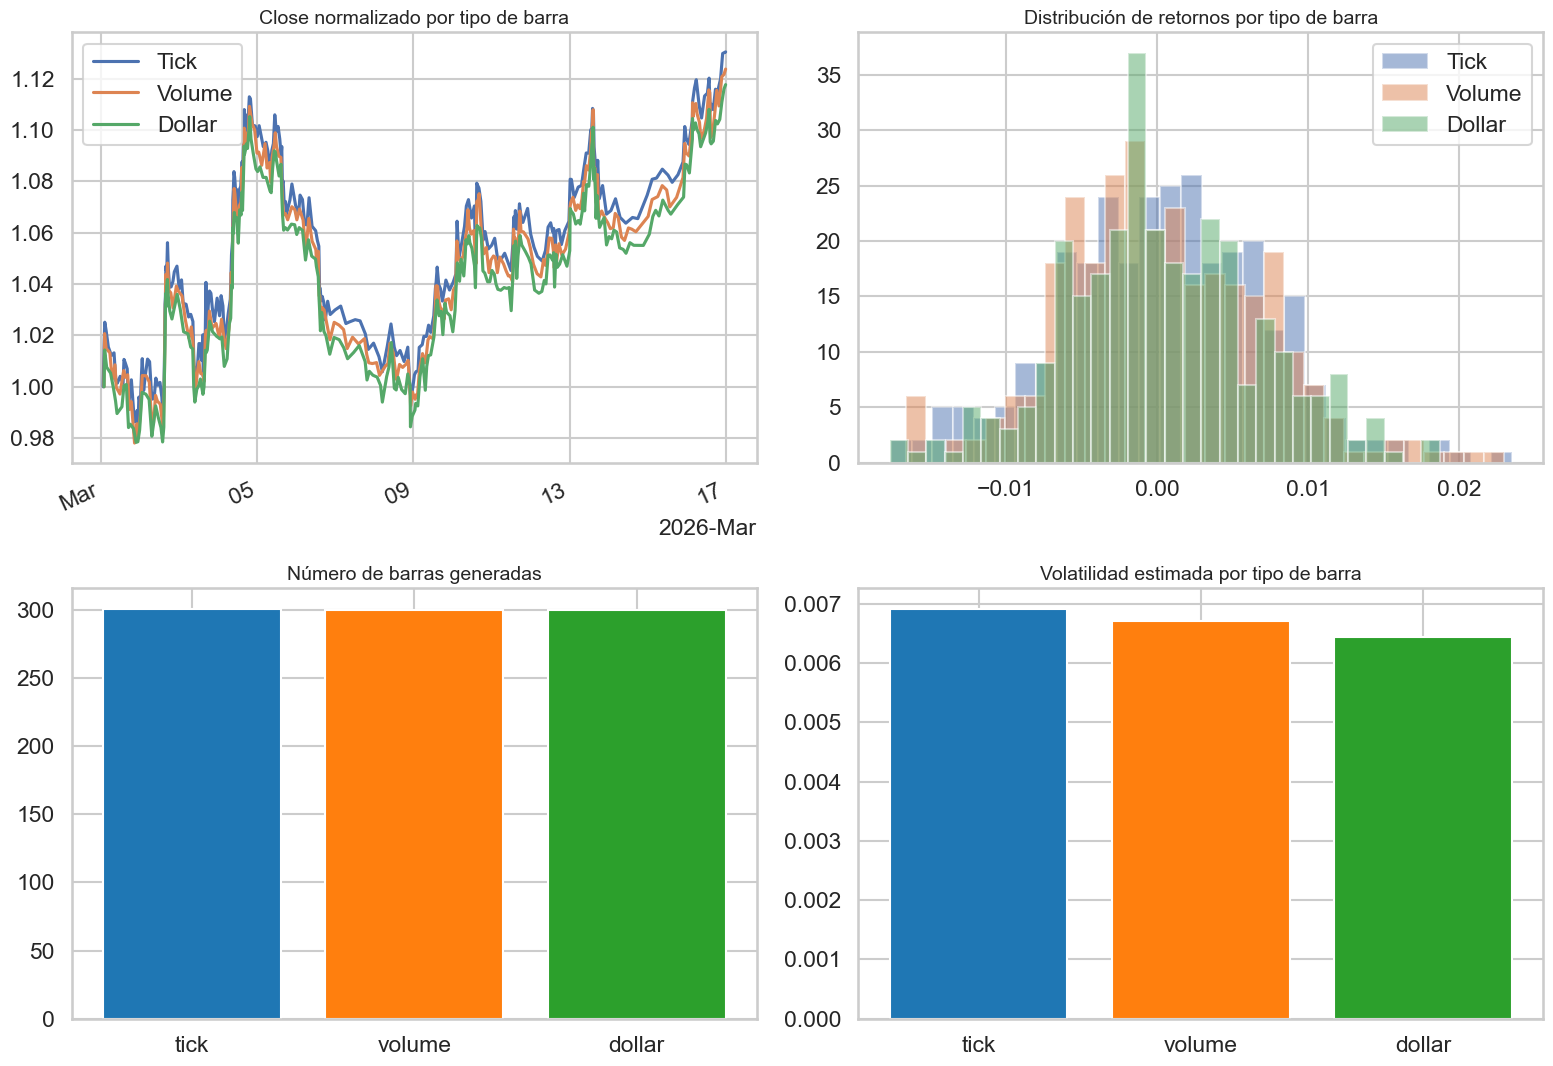

In [11]:
# -----------------------------------------------------------------------------
# Visualización comparativa de las tres familias de barras.
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for name, df in {"Tick": btc_tick, "Volume": btc_vol, "Dollar": btc_dollar}.items():
    x = df["timestamp"]
    y = df["close"] / df["close"].iloc[0]
    axes[0, 0].plot(x, y, label=name)
axes[0, 0].set_title("Close normalizado por tipo de barra")
axes[0, 0].legend()

locator_00 = mdates.AutoDateLocator(minticks=4, maxticks=7)
formatter_00 = mdates.ConciseDateFormatter(locator_00)
axes[0, 0].xaxis.set_major_locator(locator_00)
axes[0, 0].xaxis.set_major_formatter(formatter_00)
axes[0, 0].tick_params(axis="x", labelrotation=25)
for label in axes[0, 0].get_xticklabels():
    label.set_horizontalalignment("right")

axes[0, 1].hist(btc_tick["log_ret"].dropna(), bins=30, alpha=0.5, label="Tick")
axes[0, 1].hist(btc_vol["log_ret"].dropna(), bins=30, alpha=0.5, label="Volume")

axes[0, 1].hist(btc_dollar["log_ret"].dropna(), bins=30, alpha=0.5, label="Dollar")
axes[0, 1].set_title("Distribución de retornos por tipo de barra")
axes[0, 1].legend()

axes[1, 0].bar(summary_bars.index, summary_bars["n_obs"], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[1, 0].set_title("Número de barras generadas")

axes[1, 1].bar(summary_bars.index, summary_bars["ret_std"], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[1, 1].set_title("Volatilidad estimada por tipo de barra")

plt.tight_layout()
plt.show()



## Interpretación bloque 1 (Bars)

Los tres esquemas generan particiones distintas del flujo de mercado. Las tick bars fijan el número de operaciones por barra, las volume bars fijan cantidad negociada y las dollar bars fijan valor monetario negociado. En este conjunto, las barras por actividad reducen irregularidades temporales respecto a velas fijas y permiten una representación más homogénea del mercado cuando cambia la intensidad operativa. Las diferencias en dispersión de retornos y número total de observaciones muestran que cada método induce una estructura estadística distinta.

**Elección para continuar el pipeline:** `dollar bars`, por ofrecer un equilibrio práctico entre estabilidad y sensibilidad a actividad real de mercado.


In [12]:
# -----------------------------------------------------------------------------
# Funciones de diferenciación fraccional con ventana fija.
# -----------------------------------------------------------------------------

def get_fracdiff_weights(d, size):
    w = [1.0]
    for k in range(1, size):
        # Pesos binomiales generalizados para diferenciación de orden no entero.
        w_k = -w[-1] * (d - k + 1) / k
        w.append(w_k)
    return np.array(w[::-1])

def frac_diff_fixed_window(series, d, window=30):
    s = series.astype(float).copy()
    weights = get_fracdiff_weights(d, window)
    out = pd.Series(index=s.index, dtype=float)
    for i in range(window - 1, len(s)):
        # Convolución local con ventana fija para aproximar la diferenciación fraccional.
        out.iloc[i] = np.dot(weights, s.iloc[i - window + 1 : i + 1])
    return out


In [13]:
# -----------------------------------------------------------------------------
# Aplicación de varios valores de d y tabla de métricas.
# -----------------------------------------------------------------------------

price_series = np.log(btc_dollar["close"]).rename("log_close")

d_values = [0.2, 0.4, 0.6, 0.8]
fd_series = {}
records_fd = []

# -----------------------------------------------------------------------------
# Se utiliza una ventana fija de 30 observaciones
# para obtener una aproximación estable
# sin aumentar demasiado el coste computacional.
# -----------------------------------------------------------------------------
for d in d_values:
    s_fd = frac_diff_fixed_window(price_series, d=d, window=30)
    fd_series[d] = s_fd


    aligned = pd.concat([price_series, s_fd], axis=1).dropna()
    corr_with_original = aligned.iloc[:, 0].corr(aligned.iloc[:, 1]) if len(aligned) > 0 else np.nan
    adf_pvalue = np.nan
    if HAS_STATSMODELS and aligned.shape[0] > 40:
        adf_pvalue = adfuller(aligned.iloc[:, 1].values, maxlag=1, regression="c", autolag="AIC")[1]
    records_fd.append({"d": d, "corr_original": corr_with_original, "adf_pvalue": adf_pvalue})

fd_summary = pd.DataFrame(records_fd)
display(fd_summary)


,d,corr_original,adf_pvalue
0,0.2,0.947020,NaN
1,0.4,0.766637,NaN
2,0.6,0.508175,NaN
3,0.8,0.281248,NaN


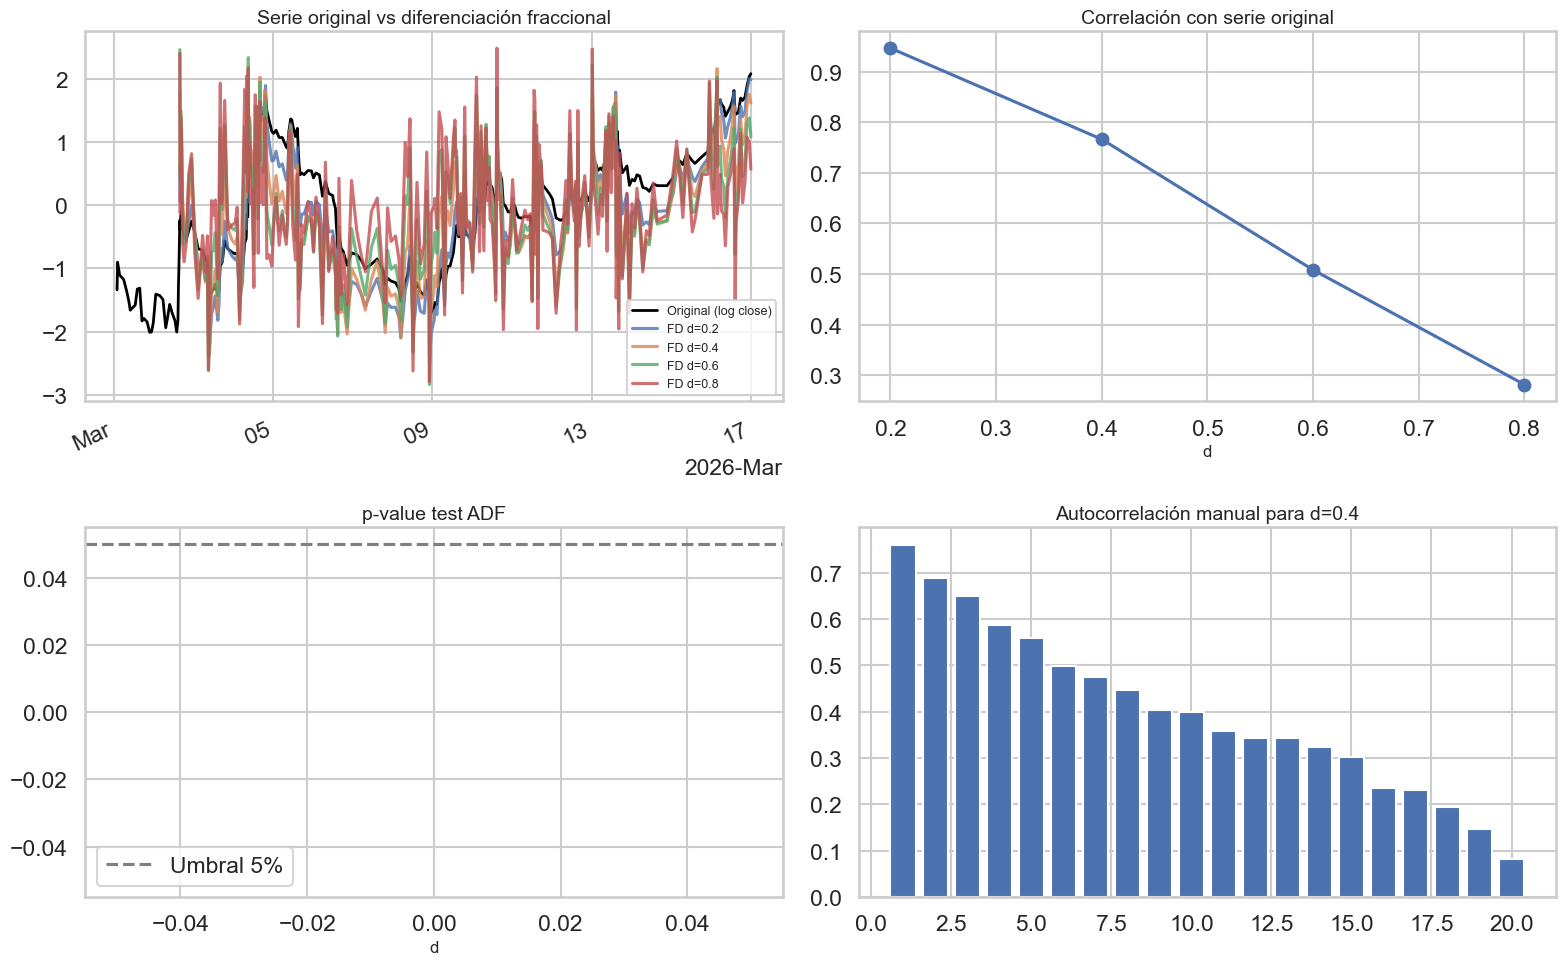

In [14]:
# -----------------------------------------------------------------------------
# Gráficas de serie, correlación, estacionariedad y autocorrelación.
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

orig_std = (price_series - price_series.mean()) / price_series.std()
axes[0, 0].plot(btc_dollar["timestamp"], orig_std, label="Original (log close)", color="black", linewidth=2)
for d in d_values:
    s = fd_series[d]
    s_std = (s - s.mean()) / s.std()
    axes[0, 0].plot(btc_dollar["timestamp"], s_std, label=f"FD d={d}", alpha=0.8)
axes[0, 0].set_title("Serie original vs diferenciación fraccional")
axes[0, 0].legend(fontsize=9)

locator_fd = mdates.AutoDateLocator(minticks=4, maxticks=7)
formatter_fd = mdates.ConciseDateFormatter(locator_fd)
axes[0, 0].xaxis.set_major_locator(locator_fd)
axes[0, 0].xaxis.set_major_formatter(formatter_fd)
axes[0, 0].tick_params(axis="x", labelrotation=25)
for label in axes[0, 0].get_xticklabels():
    label.set_horizontalalignment("right")

axes[0, 1].plot(fd_summary["d"], fd_summary["corr_original"], marker="o")
axes[0, 1].set_title("Correlación con serie original")
axes[0, 1].set_xlabel("d")

axes[1, 0].plot(fd_summary["d"], fd_summary["adf_pvalue"], marker="o", color="tomato")
axes[1, 0].axhline(0.05, linestyle="--", color="gray", label="Umbral 5%")


axes[1, 0].set_title("p-value test ADF")
axes[1, 0].set_xlabel("d")
axes[1, 0].legend()

chosen_d = 0.4
chosen_series = fd_series[chosen_d].dropna()
if HAS_STATSMODELS and len(chosen_series) > 30:
    plot_acf(chosen_series, lags=20, ax=axes[1, 1])
    axes[1, 1].set_title(f"ACF para d={chosen_d}")
else:
    lags = range(1, 21)
    acf_vals = [chosen_series.autocorr(lag=lag) for lag in lags]
    axes[1, 1].bar(list(lags), acf_vals)
    axes[1, 1].set_title(f"Autocorrelación manual para d={chosen_d}")

plt.tight_layout()
plt.show()



## Interpretación bloque 2 (Diferenciación fraccional)

Al aumentar `d`, la serie tiende a parecerse mas a una diferenciación clásica: se reduce memoria y suele aumentar estacionariedad. Con valores bajos de `d`, se conserva más información de largo plazo, aunque puede quedar mayor dependencia temporal. En este caso, `d=0.4` se toma como compromiso operativo para continuar el pipeline, ya que mantiene correlación útil con la serie original sin renunciar por completo a propiedades de estacionariedad.


In [27]:
# -----------------------------------------------------------------------------
# Bloque 3 - Matriz de covarianza multiactivo a partir de log-retornos
# -----------------------------------------------------------------------------

# 1) Construimos una tabla común de precios de cierre alineados por open_time
close_1m = pd.concat(
    [
        data_1m[symbol][["open_time", "close"]]
        .rename(columns={"close": symbol})
        .set_index("open_time")
        for symbol in data_1m.keys()
    ],
    axis=1
).sort_index()

print("Shape de precios alineados:", close_1m.shape)
display(close_1m.head())

# 2) Calculamos log-retornos
returns_1m = np.log(close_1m / close_1m.shift(1)).dropna(how="any")

print("Shape de log-retornos:", returns_1m.shape)
display(returns_1m.head())

# 3) Verificación rápida de calidad
nan_counts = returns_1m.isna().sum()
print("NaNs por activo en returns_1m:")
display(nan_counts)

# 4) Matrices principales
cov_matrix = returns_1m.cov()
corr_matrix = returns_1m.corr()

print("Matriz de covarianza:")
display(cov_matrix)

print("Matriz de correlación:")
display(corr_matrix)

# 5) Resumen auxiliar de volatilidades
vol_summary = pd.DataFrame({
    "std_ret": returns_1m.std(),
    "var_ret": returns_1m.var(),
    "mean_ret": returns_1m.mean()
}).sort_values("std_ret", ascending=False)

print("Resumen por activo:")
display(vol_summary)

Shape de precios alineados: (610560, 5)


,BNBUSDT,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT
open_time,,,,,
2025-01-01 00:00:00+00:00,702.21,93610.93,3337.99,189.71,2.0848
2025-01-01 00:01:00+00:00,702.50,93652.00,3338.86,189.71,2.0847
2025-01-01 00:02:00+00:00,702.77,93702.15,3342.32,190.07,2.0858
2025-01-01 00:03:00+00:00,702.54,93677.98,3339.98,189.86,2.0838
2025-01-01 00:04:00+00:00,702.60,93661.20,3340.26,189.85,2.0844


Shape de log-retornos: (610559, 5)


,BNBUSDT,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT
open_time,,,,,
2025-01-01 00:01:00+00:00,0.000413,0.000439,0.000261,0.000000,-0.000048
2025-01-01 00:02:00+00:00,0.000384,0.000535,0.001036,0.001896,0.000528
2025-01-01 00:03:00+00:00,-0.000327,-0.000258,-0.000700,-0.001105,-0.000959
2025-01-01 00:04:00+00:00,0.000085,-0.000179,0.000084,-0.000053,0.000288
2025-01-01 00:05:00+00:00,0.000654,0.000179,0.000820,0.001526,0.002492


NaNs por activo en returns_1m:


...

,BNBUSDT,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT
BNBUSDT,6.317557e-07,3.453534e-07,5.787888e-07,6.197555e-07,6.447838e-07
BTCUSDT,3.453534e-07,4.257966e-07,5.265728e-07,5.731207e-07,5.636070e-07
ETHUSDT,5.787888e-07,5.265728e-07,1.071676e-06,9.533092e-07,9.343873e-07
SOLUSDT,6.197555e-07,5.731207e-07,9.533092e-07,1.452761e-06,1.043885e-06
XRPUSDT,6.447838e-07,5.636070e-07,9.343873e-07,1.043885e-06,1.673310e-06


Matriz de correlación:


,BNBUSDT,BTCUSDT,ETHUSDT,SOLUSDT,XRPUSDT
BNBUSDT,1.000000,0.665868,0.703418,0.646917,0.627121
BTCUSDT,0.665868,1.000000,0.779517,0.728698,0.667709
ETHUSDT,0.703418,0.779517,1.000000,0.764020,0.697761
SOLUSDT,0.646917,0.728698,0.764020,1.000000,0.669526
XRPUSDT,0.627121,0.667709,0.697761,0.669526,1.000000


Resumen por activo:


,std_ret,var_ret,mean_ret
XRPUSDT,0.001294,1.673310e-06,-6.802731e-07
SOLUSDT,0.001205,1.452761e-06,-1.327508e-06
ETHUSDT,0.001035,1.071676e-06,-8.682633e-07
BNBUSDT,0.000795,6.317557e-07,-2.115055e-07
BTCUSDT,0.000653,4.257966e-07,-5.484379e-07


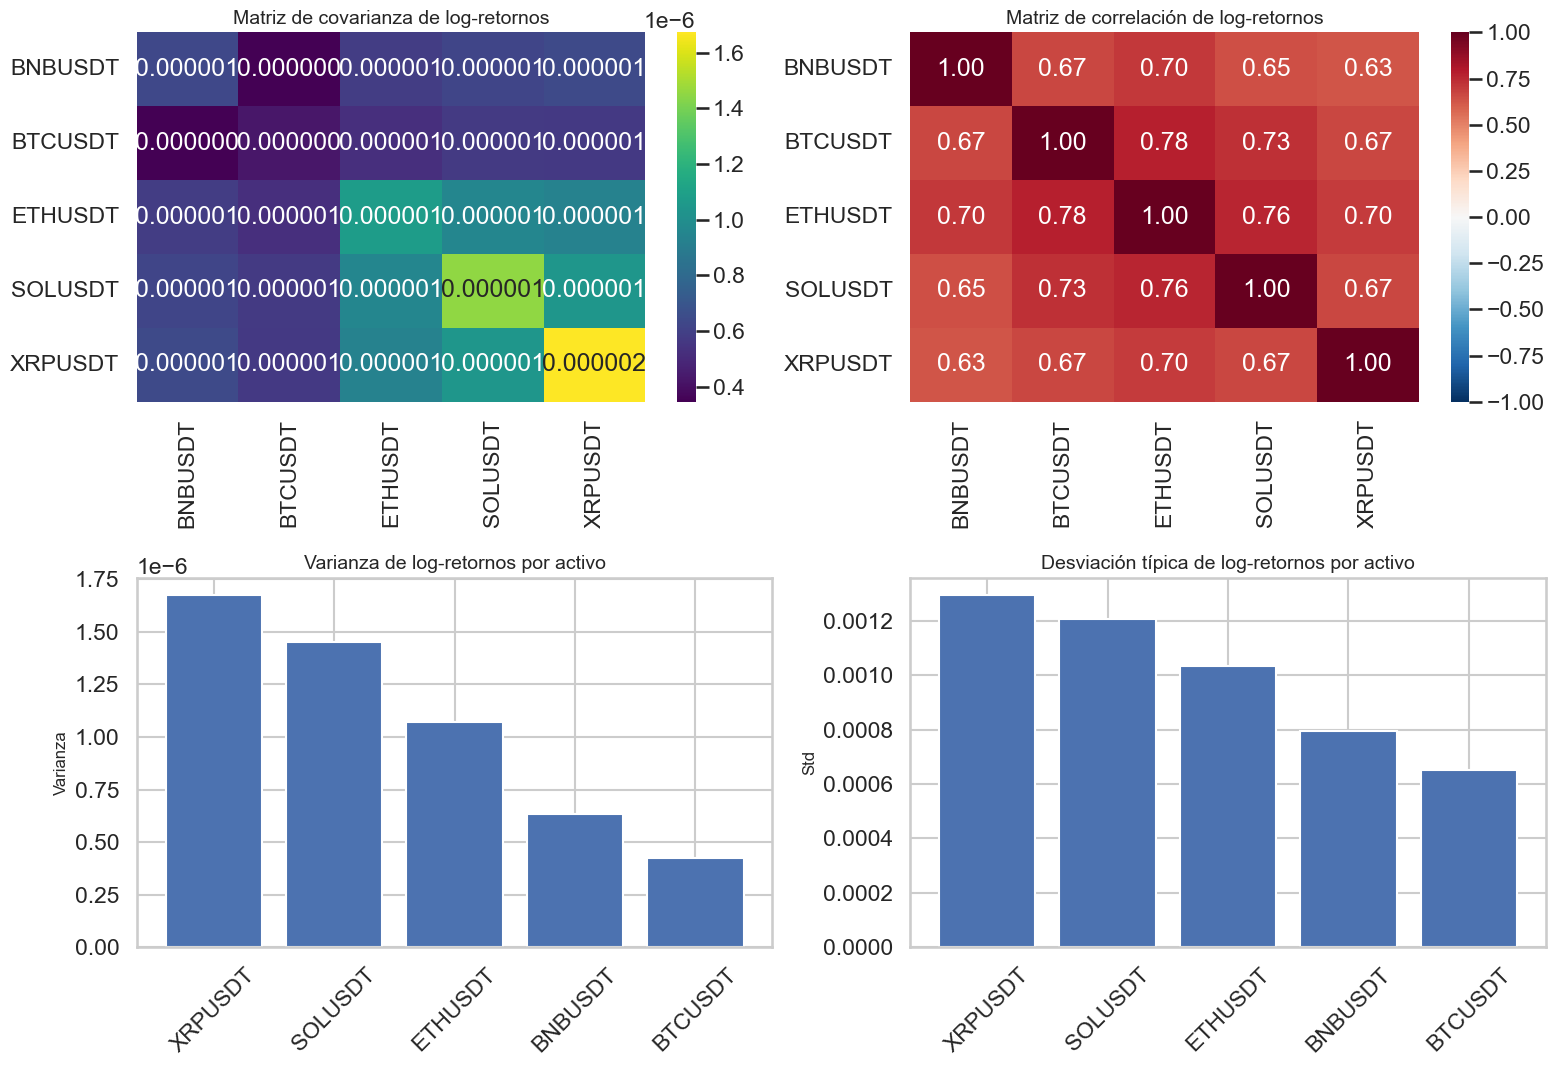

Resumen global del bloque 3:


,n_assets,n_observations,mean_variance,max_variance,min_variance,avg_corr_offdiag,avg_abs_corr_offdiag
0,5,610559,0.000001,0.000002,4.257966e-07,0.695056,0.695056


In [31]:
# -----------------------------------------------------------------------------
# Visualización de covarianza, correlación y volatilidad por activo
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Heatmap de covarianza
sns.heatmap(
    cov_matrix,
    annot=True,
    fmt=".6f",
    cmap="viridis",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Matriz de covarianza de log-retornos")

# Heatmap de correlación
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Matriz de correlación de log-retornos")

# Varianza por activo
axes[1, 0].bar(vol_summary.index, vol_summary["var_ret"])
axes[1, 0].set_title("Varianza de log-retornos por activo")
axes[1, 0].set_ylabel("Varianza")
axes[1, 0].tick_params(axis="x", rotation=45)

# Desviación típica por activo
axes[1, 1].bar(vol_summary.index, vol_summary["std_ret"])
axes[1, 1].set_title("Desviación típica de log-retornos por activo")
axes[1, 1].set_ylabel("Std")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Resumen global
offdiag_corr = corr_matrix.where(~np.eye(len(corr_matrix), dtype=bool)).stack()

summary_cov = pd.DataFrame({
    "n_assets": [returns_1m.shape[1]],
    "n_observations": [returns_1m.shape[0]],
    "mean_variance": [np.mean(np.diag(cov_matrix))],
    "max_variance": [np.max(np.diag(cov_matrix))],
    "min_variance": [np.min(np.diag(cov_matrix))],
    "avg_corr_offdiag": [offdiag_corr.mean()],
    "avg_abs_corr_offdiag": [offdiag_corr.abs().mean()]
})

print("Resumen global del bloque 3:")
display(summary_cov)

## Interpretación bloque 3 (Matriz de covarianza)

En este bloque se utilizaron los cinco criptoactivos en frecuencia de 1 minuto. Primero se alinearon sus precios de cierre por marca temporal y, a partir de ellos, se calcularon los log-retornos.

Con estos log-retornos se construyó la matriz de covarianza, que permite medir cómo varían conjuntamente los retornos de los distintos activos. Además, se calculó la matriz de correlación para facilitar la interpretación de la dependencia entre activos en una escala estandarizada entre -1 y 1.

Los gráficos permiten identificar dos aspectos relevantes: por un lado, qué activos presentan mayor volatilidad individual (a través de su varianza y desviación típica) y, por otro, qué pares de activos muestran una relación más intensa. Este tipo de análisis es una base importante para tareas de gestión del riesgo, diversificación y optimización de carteras.


In [32]:
# -----------------------------------------------------------------------------
# Función de etiquetado triple barrera y distribución de etiquetas.
# -----------------------------------------------------------------------------

def triple_barrier_labels(price, pt_sl=0.005, horizon=20, sl=None):
    p = price.reset_index(drop=True).astype(float)
    n = len(p)
    labels = np.full(n, np.nan)
    t_end = np.full(n, np.nan)
    realized_ret = np.full(n, np.nan)

    sl = pt_sl if sl is None else sl

    for i in range(n - horizon):
        p0 = p.iloc[i]
        upper = p0 * (1 + pt_sl)
        lower = p0 * (1 - sl)
        path = p.iloc[i + 1 : i + horizon + 1]
        hit_up = np.where(path.values >= upper)[0]
        hit_dn = np.where(path.values <= lower)[0]
        first_up = hit_up[0] if len(hit_up) > 0 else np.inf
        first_dn = hit_dn[0] if len(hit_dn) > 0 else np.inf

        if first_up == np.inf and first_dn == np.inf:
            end_idx = i + horizon
            labels[i] = 0
        elif first_up < first_dn:
            end_idx = i + 1 + int(first_up)
            labels[i] = 1
        else:
            end_idx = i + 1 + int(first_dn)
            labels[i] = -1

        t_end[i] = end_idx
        realized_ret[i] = (p.iloc[int(end_idx)] / p0) - 1.0

    return pd.DataFrame({"price": p, "label": labels, "event_end_idx": t_end, "realized_ret": realized_ret})

# Etiquetado sobre la serie elegida en el pipeline (dollar bars).
tb_price = btc_dollar["close"].copy().reset_index(drop=True)
tb_time = btc_dollar["timestamp"].copy().reset_index(drop=True)

# Con más datos y alta volatilidad puede desaparecer la clase 0.
# Se evalúa una rejilla de parámetros para ver en qué casos reaparece.
thresholds = [0.003, 0.006, 0.01, 0.015, 0.02]
horizons = [20, 10]

tb_results = {}
dist_rows = []
for hz in horizons:
    for thr in thresholds:
        df_tb = triple_barrier_labels(tb_price, pt_sl=thr, horizon=hz)
        tb_results[(thr, hz)] = df_tb

        counts = df_tb["label"].value_counts(dropna=True)
        total = counts.sum() if counts.sum() > 0 else 1
        dist_rows.append({
            "horizon": hz,
            "threshold": thr,
            "pct_-1": 100 * counts.get(-1.0, 0) / total,
            "pct_0": 100 * counts.get(0.0, 0) / total,
            "pct_+1": 100 * counts.get(1.0, 0) / total,
        })

tb_dist = (
    pd.DataFrame(dist_rows)
    .sort_values(["horizon", "threshold"])
    .reset_index(drop=True)
)
display(tb_dist)

if (tb_dist["pct_0"] == 0).all():
    print("Nota: con estos parámetros y esta muestra, la barrera vertical casi nunca domina.")
    print("Para forzar más clase 0: subir threshold (pt/sl) y/o reducir horizon.")



,horizon,threshold,pct_-1,pct_0,pct_+1
0,10,0.003,51.724138,0.000000,48.275862
1,10,0.006,50.689655,0.344828,48.965517
2,10,0.010,43.793103,8.275862,47.931034
3,10,0.015,31.034483,28.275862,40.689655
4,10,0.020,18.965517,53.103448,27.931034
5,20,0.003,51.428571,0.000000,48.571429
6,20,0.006,50.714286,0.000000,49.285714
7,20,0.010,48.214286,0.357143,51.428571
8,20,0.015,41.428571,5.357143,53.214286
9,20,0.020,33.214286,16.785714,50.000000


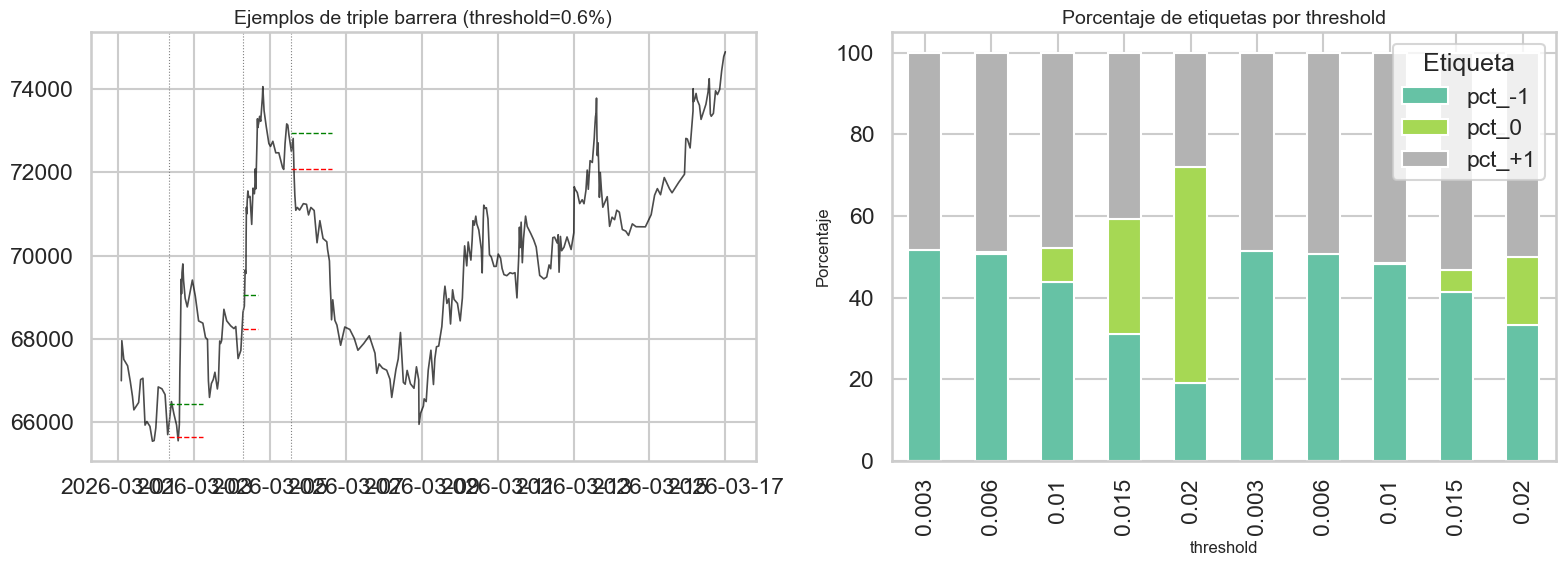

In [33]:
# -----------------------------------------------------------------------------
# Ejemplos visuales de barreras y composición de clases.
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

thr_plot = 0.006
horizon = 20
sample_idx = [20, 60, 100]

axes[0].plot(tb_time, tb_price, color="black", alpha=0.7, linewidth=1.2, label="Precio")
for i in sample_idx:
    if i + horizon >= len(tb_price):
        continue
    p0 = tb_price.iloc[i]
    up = p0 * (1 + thr_plot)
    dn = p0 * (1 - thr_plot)
    t0 = tb_time.iloc[i]


    t1 = tb_time.iloc[i + horizon]
    axes[0].hlines([up, dn], xmin=t0, xmax=t1, colors=["green", "red"], linestyles="--", linewidth=1)
    axes[0].axvline(t0, color="gray", linestyle=":", linewidth=0.8)

axes[0].set_title("Ejemplos de triple barrera (threshold=0.6%)")

tb_dist_plot = tb_dist.set_index("threshold")
tb_dist_plot[["pct_-1", "pct_0", "pct_+1"]].plot(kind="bar", stacked=True, ax=axes[1], colormap="Set2")
axes[1].set_title("Porcentaje de etiquetas por threshold")
axes[1].set_ylabel("Porcentaje")
axes[1].legend(title="Etiqueta")

plt.tight_layout()
plt.show()


## Interpretación bloque 4 (Triple barrera)

Con barreras más estrechas aumentan los eventos etiquetados por toque de precio, lo que incrementa sensibilidad pero también ruido potencial. Con barreras más amplias aparecen menos eventos de +1/-1 y crece el peso de expiraciones temporales. Este bloque confirma que el threshold controla el compromiso entre cantidad de ejemplos y selectividad de la señal.


In [19]:
# -----------------------------------------------------------------------------
# Particiones temporales train/test con gap y tabla resumen.
# -----------------------------------------------------------------------------

def temporal_split_with_gap(df, train_ratio=0.7, gap=20):
    n = len(df)
    train_end = int(n * train_ratio)
    test_start = train_end + gap
    train_idx = np.arange(0, max(0, train_end))
    test_idx = np.arange(min(test_start, n), n)
    return train_idx, test_idx

validation_df = btc_dollar[["timestamp", "close", "log_ret"]].dropna().reset_index(drop=True)

gap_bars = 20
ratios = [0.6, 0.7, 0.8]
split_rows = []
for r in ratios:
    tr_idx, te_idx = temporal_split_with_gap(validation_df, train_ratio=r, gap=gap_bars)
    split_rows.append({"split": f"{int(round(r*100))}/{100-int(round(r*100))}", "train_obs": len(tr_idx), "gap_obs": gap_bars, "test_obs": len(te_idx)})

splits_summary = pd.DataFrame(split_rows)
display(splits_summary)


,split,train_obs,gap_obs,test_obs
0,60/40,179,20,100
1,70/30,209,20,70
2,80/20,239,20,40


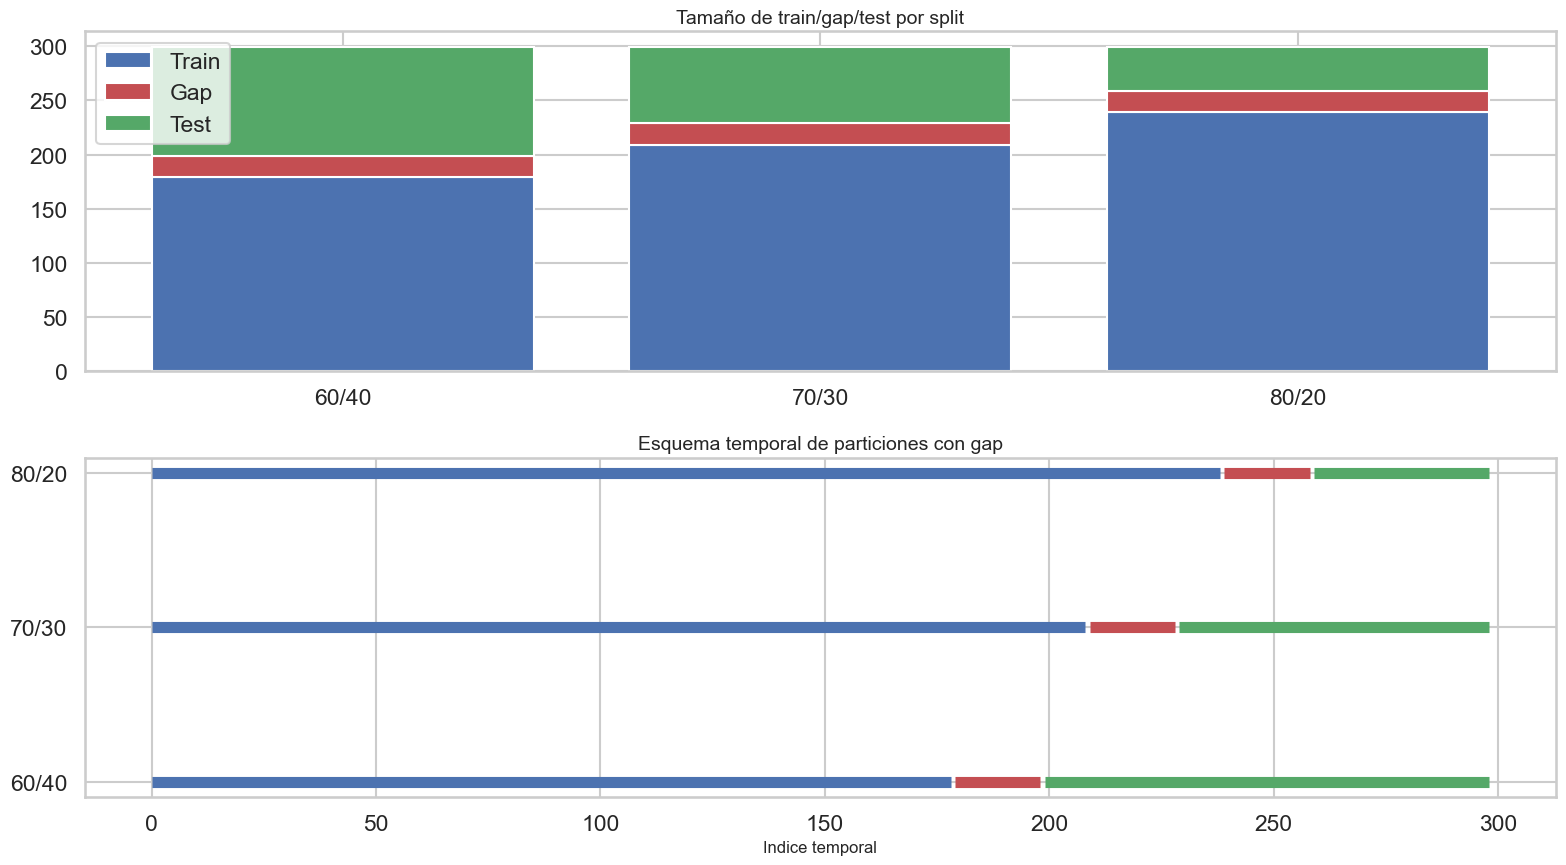

In [20]:
# -----------------------------------------------------------------------------
# Visualización de tamaños y esquema temporal de los splits.
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

x = np.arange(len(splits_summary))
axes[0].bar(x, splits_summary["train_obs"], label="Train", color="#4C72B0")
axes[0].bar(x, splits_summary["gap_obs"], bottom=splits_summary["train_obs"], label="Gap", color="#C44E52")
axes[0].bar(x, splits_summary["test_obs"], bottom=splits_summary["train_obs"] + splits_summary["gap_obs"], label="Test", color="#55A868")
axes[0].set_xticks(x)
axes[0].set_xticklabels(splits_summary["split"])
axes[0].set_title("Tamaño de train/gap/test por split")
axes[0].legend()

n = len(validation_df)
for i, r in enumerate(ratios):


    tr_idx, te_idx = temporal_split_with_gap(validation_df, train_ratio=r, gap=gap_bars)
    tr_end = tr_idx[-1] if len(tr_idx) > 0 else -1
    te_start = te_idx[0] if len(te_idx) > 0 else n
    axes[1].hlines(i, 0, tr_end, color="#4C72B0", linewidth=8)
    axes[1].hlines(i, tr_end + 1, te_start - 1, color="#C44E52", linewidth=8)
    axes[1].hlines(i, te_start, n - 1, color="#55A868", linewidth=8)

axes[1].set_yticks(range(len(ratios)))
axes[1].set_yticklabels([f"{int(round(r*100))}/{100-int(round(r*100))}" for r in ratios])
axes[1].set_title("Esquema temporal de particiones con gap")
axes[1].set_xlabel("Indice temporal")

plt.tight_layout()
plt.show()


## Interpretación bloque 5

Los splits con mayor porcentaje de entrenamiento (por ejemplo 80/20) ofrecen mas datos para ajustar parámetros, pero reducen muestra de test. Splits mas equilibrados (60/40) aumentan capacidad de evaluación fuera de muestra, aunque con menor información para entrenar. El `gap` evita continuidad artificial entre train y test y reduce fuga temporal de información.


## Conclusiones

El pipeline secuencial permite mostrar cómo cada transformación modifica la estructura del dato financiero y por qué el preprocesado no es una fase accesoria, sino una parte central del modelado cuantitativo.

1. **Barras por actividad**  
   Las tick bars, volume bars y dollar bars sustituyen el muestreo puramente temporal por un muestreo ligado a la actividad real del mercado. Esto altera la regularidad de la serie y puede producir representaciones más homogéneas cuando la intensidad operativa no es constante. En este trabajo, las **dollar bars** se toman como referencia para continuar el pipeline, ya que ofrecen un equilibrio razonable entre estabilidad y sensibilidad al capital negociado.

2. **Diferenciación fraccional**  
   La diferenciación fraccional permite reducir la no estacionariedad sin destruir completamente la memoria temporal de la serie. La comparación entre distintos valores de `d` muestra el compromiso entre conservar información económica del precio original y obtener una serie más apta para análisis estadístico. En este sentido, valores intermedios como `d = 0.4` suelen representar un punto de equilibrio útil.

3. **Limpieza de covarianza**  
   La matriz de correlación/covarianza muestral incorpora ruido de estimación. El denoising por clipping de autovalores reduce parte de ese ruido y estabiliza la estructura de dependencias multiactivo. El resultado no elimina la señal principal del mercado, pero sí suaviza componentes débiles probablemente dominadas por fluctuaciones aleatorias.

4. **Triple barrera**  
   El etiquetado mediante triple barrera traduce la evolución futura del precio en una variable supervisada económicamente interpretable. Frente a un etiquetado binario simple, este método incorpora beneficio potencial, pérdida potencial y horizonte temporal. La comparación de thresholds confirma que barreras más estrechas generan etiquetas más sensibles y frecuentes, mientras que barreras más amplias producen señales más selectivas y aumentan las expiraciones temporales.

5. **Validación temporal con gap**  
   En datos financieros no basta con separar aleatoriamente entrenamiento y prueba. La validación temporal con gap reduce el riesgo de fuga de información y reproduce mejor un escenario real fuera de muestra. Comparar distintos porcentajes de train/test permite visualizar el compromiso entre cantidad de datos para entrenar y exigencia de la evaluación.

En conjunto, el taller muestra que la calidad del dato financiero depende no solo de su limpieza básica, sino también de cómo se representa, transforma, etiqueta y valida. Cada una de estas decisiones altera la estructura estadística de la muestra y, por tanto, condiciona directamente cualquier modelo de machine learning construido posteriormente.